In [40]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [41]:
load_dotenv()

True

In [42]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [43]:
llm = ChatGoogleGenerativeAI( model = "gemini-3.1-flash-lite" )

In [44]:
def chat_node(state: ChatState):
    
    # Take user query from state
    messages = state['messages']
    
    # Send to llm
    response = llm.invoke(messages)
    
    # Store Response state
    return {'messages': response}

In [45]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# Add Nodes
graph.add_node('chat_node', chat_node)

# Add Edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

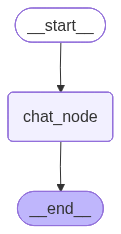

In [46]:
chatbot

In [ ]:
# initial_state: ChatState = {
#     'messages': [ HumanMessage(content="Explain is state reducer in langgraph? ") ]
# }

# chatbot.invoke(initial_state)['messages'][1].content[0]['text']

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [51]:
from langchain_core.runnables import RunnableConfig

thread_id = '1'


while True:
    
    user_message = input("The your message here...")
    
    print("User: ", user_message)
    
    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        print("AI: Have a great day, Good bye!")
        break
    
    # config = {
    #     'configurable': {'thread_id': thread_id}
    # }
    
    config: RunnableConfig = {
        'configurable': {'thread_id': thread_id}
    }

    response = chatbot.invoke(
        {'messages': [HumanMessage(content=user_message)]},
        config=config
    )
    
    print("AI: ", response['messages'][-1].content[0]['text'])

User:  Hey, I am Yash
AI:  Welcome back, Yash! How can I help you today?
User:  Tell me my name
AI:  Your name is **Yash**.
User:  add 23 and 45
AI:  23 plus 45 is **68**.
User:  subtract 70 from result
AI:  The result of your previous calculation was 68. Subtracting 70 from 68 gives you **-2**.
User:  bye
AI: Have a great day, Good bye!


In [ ]:
chatbot.get_state(config=config)